lambda = 10.0

B =
[[1.+0.j 3.+0.j 2.+0.j 4.+0.j]
 [3.+0.j 1.+0.j 4.+0.j 2.+0.j]
 [2.+0.j 4.+0.j 1.+0.j 3.+0.j]
 [4.+0.j 2.+0.j 3.+0.j 1.+0.j]]


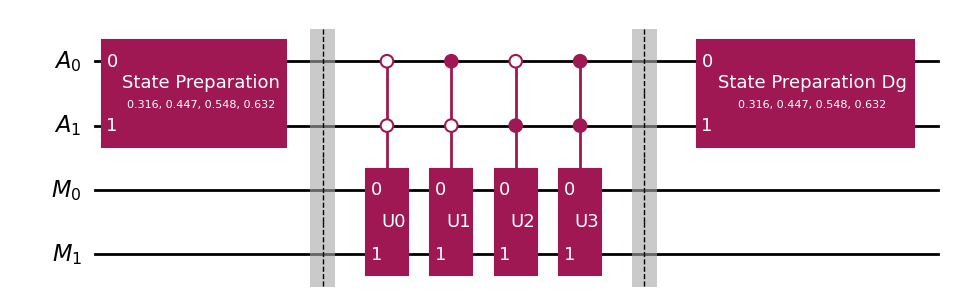


FULL OUTPUT STATE:


<IPython.core.display.Latex object>


--------------------------------------------
TERMS WITH ANCILLA = 00
--------------------------------------------
|0000> : (0.10000000000000019+1.248442224881509e-15j)
|0100> : (0.29999999999999877-1.030094809041562e-15j)
|1000> : (0.20000000000000095-1.5298667232958863e-15j)
|1100> : (0.4000000000000013-4.857422177968801e-16j)

Quantum circuit result for ancilla = 00:
[0.1+1.24844222e-15j 0.3-1.03009481e-15j 0.2-1.52986672e-15j
 0.4-4.85742218e-16j]

Classically calculated (B/lambda)|psi>:
[0.1+0.j 0.3+0.j 0.2+0.j 0.4+0.j]

Do they match?
True


In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit.quantum_info import *
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit.circuit.library import UnitaryGate, StatePreparation
from numpy import pi
from qiskit_aer import AerSimulator
import numpy as np
import math
import random



# FOUR UNITARIES


I = np.eye(2, dtype=complex)

X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

U0 = np.kron(I, I)
U1 = np.kron(X, I)
U2 = np.kron(I, X)
U3 = np.kron(X, X)

U_list = [U0, U1, U2, U3]



# COEFFICIENTS


beta = np.array([1, 2, 3, 4], dtype=float)

lam = np.sum(beta)

B = sum(beta[x] * U_list[x] for x in range(4))

print("lambda =", lam)

print("\nB =")
print(B)



# REGISTERS


anc = QuantumRegister(2, 'A')
main = QuantumRegister(2, 'M')

qc = QuantumCircuit(anc, main)



# PREP


prep_amplitudes = np.sqrt(beta / lam)

PREP = StatePreparation(prep_amplitudes)

qc.append(PREP, anc)

qc.barrier()



# SEL


for x in range(4):

    gate = UnitaryGate(U_list[x], label=f'U{x}')

    controlled_gate = gate.control(
        num_ctrl_qubits=2,
        ctrl_state=x
    )

    qc.append(
        controlled_gate,
        [anc[0], anc[1], main[0], main[1]]
    )

qc.barrier()



# PREP dagger


qc.append(PREP.inverse(), anc)



# DRAW CIRCUIT


display(qc.draw('mpl'))


# DIRECT STATEVECTOR EVOLUTION


# Initial state:
#
# |M1 M0 A1 A0> = |0000>
#
# Therefore:
# ancilla = |00>
# main    = |00>
#
initial_state = Statevector.from_label('0000')

output_state = initial_state.evolve(qc)


print("\nFULL OUTPUT STATE:")
display(output_state.draw('latex'))



# EXTRACT ONLY TERMS WHOSE LAST TWO BITS ARE 00


print("\n--------------------------------------------")
print("TERMS WITH ANCILLA = 00")
print("--------------------------------------------")

for i, amplitude in enumerate(output_state.data):

    # Convert index into 4-bit basis label
    basis = format(i, '04b')

    # last two bits correspond to A1 A0
    if basis[-2:] == '00' and abs(amplitude) > 1e-10:

        print(f"|{basis}> : {amplitude}")



# FORM THE MAIN-REGISTER VECTOR FOR ANCILLA = 00


# States having last two bits 00 are:
#
# |0000>   index 0
# |0100>   index 4
# |1000>   index 8
# |1100>   index 12
#
# corresponding to main states
#
# |00>, |01>, |10>, |11>
#

quantum_result = np.array([
    output_state.data[0],
    output_state.data[4],
    output_state.data[8],
    output_state.data[12]
])


print("\nQuantum circuit result for ancilla = 00:")
print(quantum_result)



# CLASSICAL CHECK


# Initial main-register state is |psi> = |00>

psi = np.array([
    1,
    0,
    0,
    0
], dtype=complex)


# According to block encoding:
#
# ancilla = 00 branch should be
#
#       (B / lambda) |psi>
#

classical_result = (B @ psi) / lam


print("\nClassically calculated (B/lambda)|psi>:")
print(classical_result)



# CHECK WHETHER THEY MATCH


print("\nDo they match?")

print(
    np.allclose(
        quantum_result,
        classical_result
    )
)